In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [9]:
wine = load_wine()

X = wine.data
y = wine.target

print(X.shape)

(178, 13)


In [12]:
df=pd.DataFrame(X)
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [13]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

In [26]:
# Calculate the correlation matrix of the scaled data
scaled_df = pd.DataFrame(X_scaled, columns=wine.feature_names)
correlation_matrix = scaled_df.corr()
display(correlation_matrix.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351


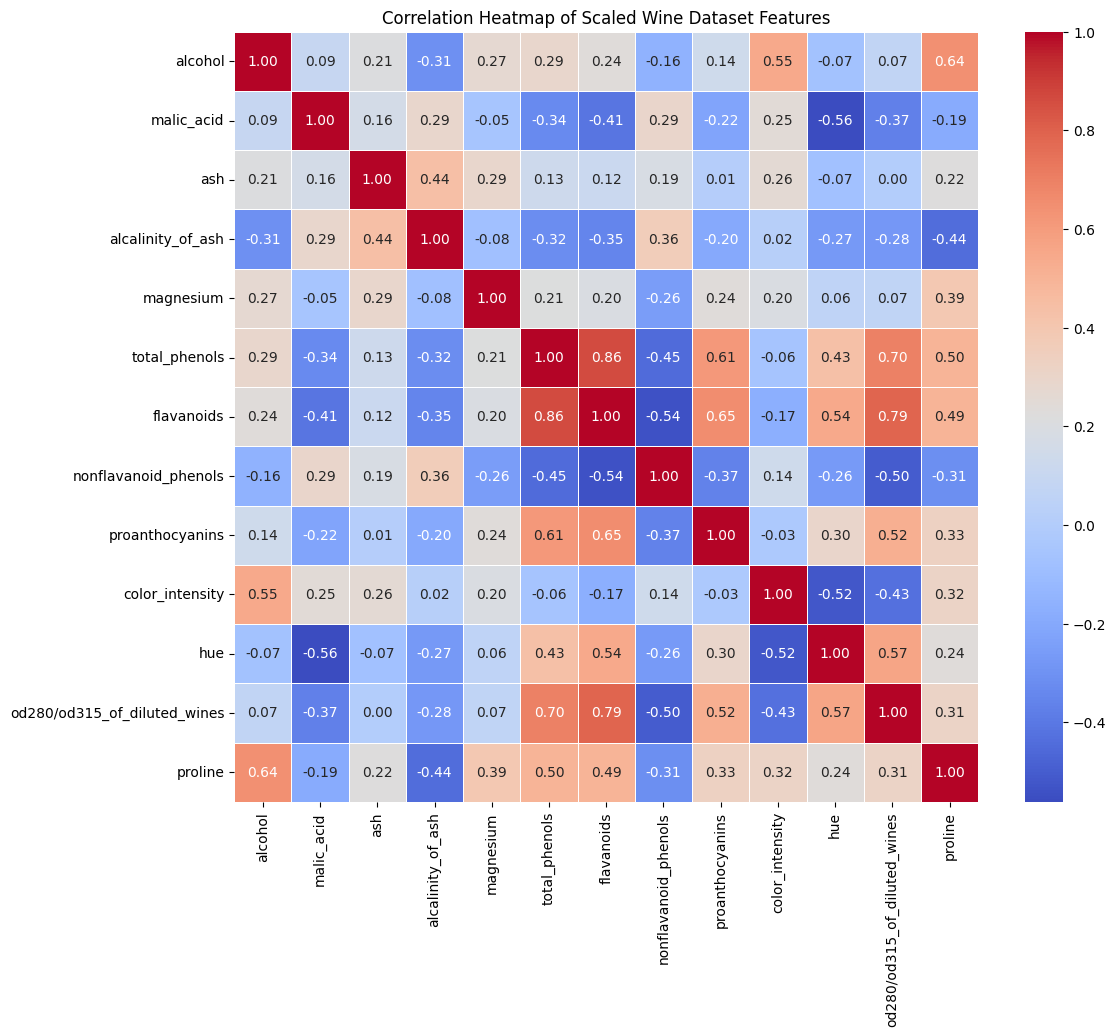

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Scaled Wine Dataset Features')
plt.show()

In [31]:

corr_pairs = correlation_matrix.unstack()
sorted_corr_pairs = corr_pairs.sort_values(ascending=False)

filtered_corr_pairs = sorted_corr_pairs[sorted_corr_pairs != 1.0]


unique_corr_list = []
seen_pairs = set()

for (feature1, feature2), correlation_value in filtered_corr_pairs.items():

    ordered_pair = tuple(sorted((feature1, feature2)))

    if ordered_pair not in seen_pairs:
        unique_corr_list.append(((feature1, feature2), correlation_value))
        seen_pairs.add(ordered_pair)


correlation_summary_df = pd.DataFrame(unique_corr_list, columns=['Feature Pair', 'Correlation'])

correlation_summary_df.head(10)

,Feature Pair,Correlation
0,"(flavanoids, total_phenols)",0.864564
1,"(flavanoids, od280/od315_of_diluted_wines)",0.787194
2,"(od280/od315_of_diluted_wines, total_phenols)",0.699949
3,"(flavanoids, proanthocyanins)",0.652692
4,"(alcohol, proline)",0.643720
5,"(total_phenols, proanthocyanins)",0.612413
6,"(hue, od280/od315_of_diluted_wines)",0.565468
7,"(color_intensity, alcohol)",0.546364
8,"(flavanoids, hue)",0.543479
9,"(proanthocyanins, od280/od315_of_diluted_wines)",0.519067


k-mean befor pca

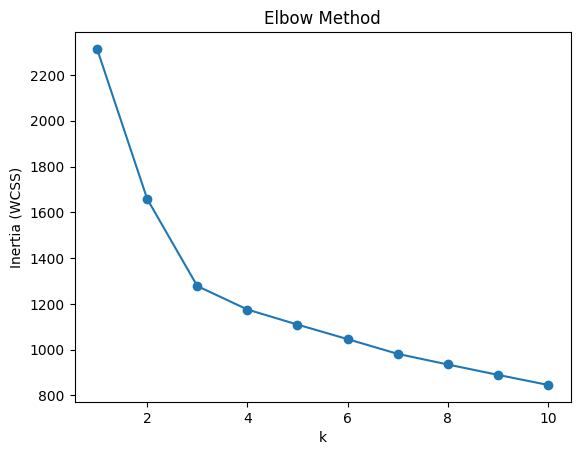

In [49]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()

In [53]:
sil_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}: silhouette = {score:.4f}")

k=2: silhouette = 0.2593
k=3: silhouette = 0.2849
k=4: silhouette = 0.2602
k=5: silhouette = 0.2016
k=6: silhouette = 0.2372
k=7: silhouette = 0.2036
k=8: silhouette = 0.1570


In [54]:
k_means=KMeans(n_clusters=3, random_state=42,n_init=10)
kme=k_means.fit_predict(X_scaled)
kme

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

PCA

In [58]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(178, 2)


In [59]:
k_meansPCA=KMeans(n_clusters=3, random_state=42,n_init=10)
kmePCA=k_means.fit_predict(X_pca)
kmePCA

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

Now, let's visualize these clusters on the PCA plot to see how well they separate the data.

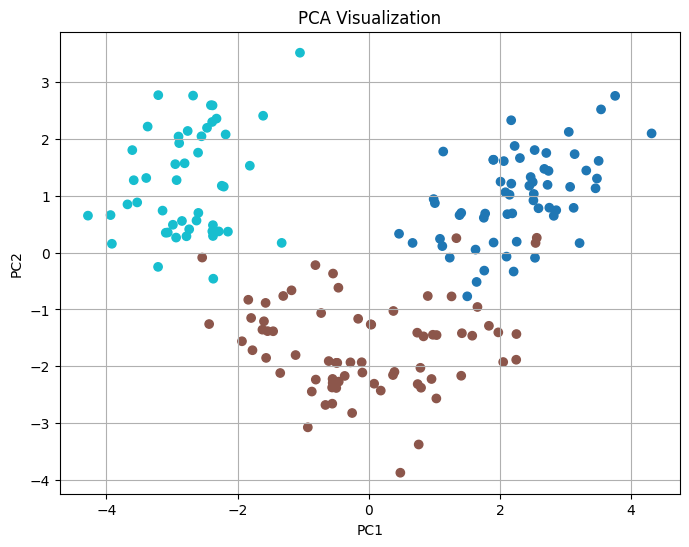

In [60]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10")
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

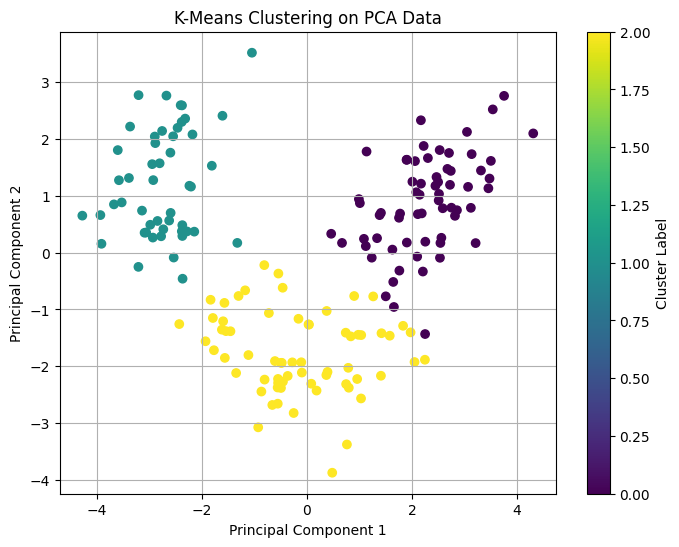

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmePCA, cmap="viridis")
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster Label')
plt.grid()
plt.show()